## Annotate the peaks-by-celltype&timepoint (pseudobulked) object

- EDA on the peaks-by-celltype&timepoint
- Annotate the peaks by the peak types (refer to ArchR)
- Annotate the peaks by the gene names (based on their proximity, or co-accessibility to TSS)
- Annotate the peaks by the TFs whose motifs were found within the peaks



In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import scipy.sparse as sp
import sys
import os
import pyranges as pr

# rapids-singlecell
import cupy as cp
import rapids_singlecell as rsc

In [2]:
# figure parameter setting
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
mpl.rcParams.update(mpl.rcParamsDefault) #Reset rcParams to default

# Editable text and proper LaTeX fonts in illustrator
# matplotlib.rcParams['ps.useafm'] = True
# Editable fonts. 42 is the magic number
mpl.rcParams['pdf.fonttype'] = 42
sns.set(style='whitegrid', context='paper')
# Set default DPI for saved figures
mpl.rcParams['savefig.dpi'] = 600

In [3]:
import logging
# Suppress INFO-level logs for the entire logger
logging.getLogger().setLevel(logging.WARNING)

In [4]:
# define the figure path
figpath = "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/zebrahub-multiome-analysis/figures/peak_umap_annotated/"
os.makedirs(figpath, exist_ok=True)
sc.settings.figdir = figpath

In [5]:
# import the peaks-by-celltype&timepoint pseudobulk object
# NOTE. the 2 MT peaks and 2 blacklisted peaks (since they go beyond the end of the chromosome) were filtered out.
# adata_peaks = sc.read_h5ad("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/objects_v2/peaks_by_pb_leiden_0.4_merged_annotated_filtered.h5ad")
adata_peaks = sc.read_h5ad("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/objects_v2/peaks_by_pb_annotated_master.h5ad")
adata_peaks

AnnData object with n_obs × n_vars = 640830 × 190
    obs: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'accessibility_neural_optic', 'accessibility_endoderm', 'accessibility_enteric_neurons', 'accessibility_notochord', 'accessibility_pharyngeal_arches', 'accessibility_floor_plate', 'accessibility_epidermis', 'accessibility_pronephros', 'accessibility_neural_floor_plate', 'accessibility_lateral_plate_mesoderm', 'accessibility_midbrain_hindbrain_boundary', 'accessibility_neural', 'accessibility_neurons', 'accessibility_neural_posterior', 'accessibility_neural_crest', 'accessibility_PSM', 'accessibility_fast_muscle', 'accessibility_endocrine_pancreas', 'accessibility_heart_myocardium', 'accessibility_neural_telencephalon', 'accessibility_optic_cup', 'accessibility_primordial_germ_cells', 'accessibility_differentiating_neurons', 'accessibility_muscle', 'accessibility_tail_bud', 'accessibility_hindbrain', 'accessibility_somites', 'accessibility_spinal_cord',

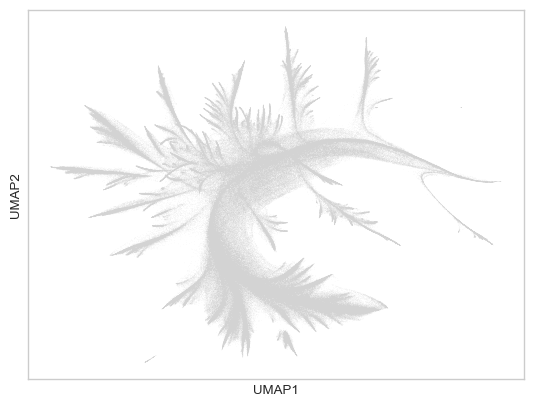

In [6]:
# Plot UMAP without colors
sc.pl.umap(adata_peaks, save="_peaks_grey.png")

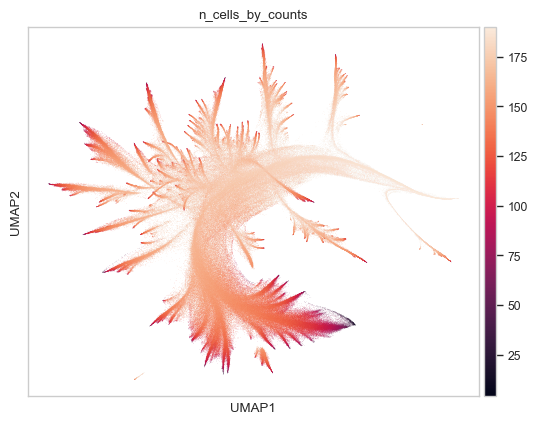

In [7]:
# Plot UMAP without colors
sc.pl.umap(adata_peaks, color="n_cells_by_counts",
           save="_peaks_n_cells_by_counts.png", palette="magma")

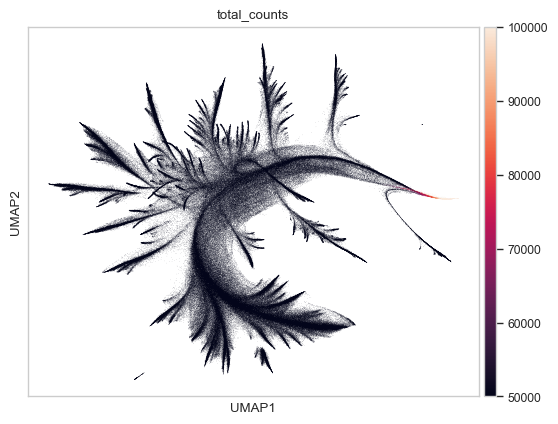

In [9]:
# Plot UMAP without colors
sc.pl.umap(adata_peaks, color="total_counts",
           save="_peaks_total_counts.png", palette="magma", vmin=50000, vmax=100000)

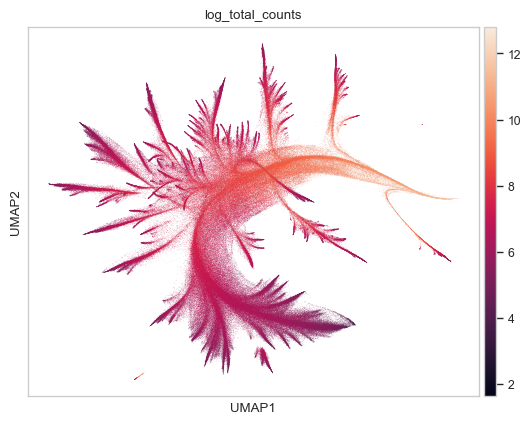

In [17]:
adata_peaks.obs["log_total_counts"] = np.log(adata_peaks.obs["total_counts"])
# Plot UMAP without colors
sc.pl.umap(adata_peaks, color="log_total_counts",
           save="_peaks_log_total_counts.png", palette="cvidis")

## Annotate the peaks using the genomic annotation

- We will refer to the Argelaguet 2022 annotation - promoter, exonic, intronic, and intergenic


In [6]:
# import the utility functions
# sys.path.append("")
from peak_annotation_utils import annotate_peak_types
help(annotate_peak_types)

Help on function annotate_peak_types in module peak_annotation_utils:

annotate_peak_types(peaks, gtf_file, upstream_promoter=2000, downstream_promoter=100)
    Annotate peaks as promoter, exonic, intronic, or intergenic
    
    Parameters:
    peaks: DataFrame with columns 'Chromosome', 'Start', 'End'
    gtf_file: Path to GTF annotation file
    upstream_promoter: bases upstream of TSS to consider as promoter (default 2000)
    downstream_promoter: bases downstream of TSS to consider as promoter (default 100)



In [12]:
adata_peaks.obs.head()

,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,accessibility_neural_optic,accessibility_endoderm,accessibility_enteric_neurons,accessibility_notochord,accessibility_pharyngeal_arches,accessibility_floor_plate,...,celltype_contrast,leiden_0.2,leiden_0.3,leiden_0.5,leiden_0.7,leiden_0.9,leiden_1,leiden_1.2,leiden_1.5,leiden_5
1-32-526,131,2.694737,31.052632,512.0,15.613128,10.325988,6.689899,2.991895,12.762588,12.170900,...,2.363813,13,16,15,15,26,16,19,28,33
1-2372-3057,162,8.294737,14.736842,1576.0,57.789060,19.729371,42.719110,17.231317,22.624311,36.413397,...,2.655166,4,3,22,1,1,2,1,2,126
1-3427-4032,170,18.636842,10.526316,3541.0,94.465606,30.845398,105.145162,41.163118,72.624480,72.500155,...,4.324834,2,7,5,6,6,6,5,7,30
1-4469-7268,190,160.247368,0.000000,30447.0,568.299814,493.321985,480.077318,535.338964,641.692987,543.858841,...,3.209961,2,4,3,3,4,4,6,4,101
1-9541-9969,172,33.905263,9.473684,6442.0,118.378152,102.449880,65.013071,141.397103,178.130543,108.393402,...,3.345182,2,7,5,6,6,6,5,7,30


In [8]:
# Convert peak names to a dataframe
peaks_df = pd.DataFrame([
    x.split('-') for x in adata_peaks.obs_names
], columns=['chrom', 'start', 'end'])

# Convert to numeric and fix column names for PyRanges
peaks_df = peaks_df.rename(columns={
    'chrom': 'Chromosome',
    'start': 'Start',
    'end': 'End'
})

# Convert to numeric
peaks_df['Chromosome'] = peaks_df['Chromosome'].astype(str)
peaks_df['Start'] = peaks_df['Start'].astype(int)
peaks_df['End'] = peaks_df['End'].astype(int)

In [9]:
# Annotate peaks (using Argelaguet 2023 definition - 500bp upstream and 100bp downstream)
gtf_file = '/hpc/reference/sequencing_alignment/alignment_references/zebrafish_genome_GRCz11/genes/genes.gtf.gz'
annotated_peaks = annotate_peak_types(peaks_df, gtf_file, 
                                      upstream_promoter=500, downstream_promoter=100)
annotated_peaks.head()

,Chromosome,Start,End,peak_type
0,1,32,526,intergenic
1,1,2372,3057,intergenic
2,1,3427,4032,intergenic
3,1,4469,7268,exonic
4,1,9541,9969,exonic


In [15]:
# using upstream=2000, and downstream=100 (as in ArchR standard)
# annotated_peaks["peak_type"].value_counts()

intronic      257818
intergenic    221262
exonic        118236
promoter       43514
Name: peak_type, dtype: int64

In [21]:
annotated_peaks["peak_type"].value_counts()

intronic      260330
intergenic    233001
exonic        121077
promoter       26422
Name: peak_type, dtype: int64

In [29]:
# save the annotated peaks
# define the output path
output_path = "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/all_peaks_annotated.csv"
annotated_peaks.to_csv(output_path, index=False)

In [25]:
# add the metadata to the adata object
adata_peaks.obs["chrom"] = annotated_peaks["Chromosome"].values
adata_peaks.obs["start"] = annotated_peaks["Start"].values
adata_peaks.obs["end"] = annotated_peaks["End"].values
adata_peaks.obs["peak_type_argelaguet"] = annotated_peaks["peak_type"].values
adata_peaks.obs.head()

# # save the adata object
# adata_peaks.obs.to_csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/objects_v2/peaks_by_pb_leiden_0.4_merged_annotated.csv", index=False)

,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,accessibility_neural_optic,accessibility_endoderm,accessibility_enteric_neurons,accessibility_notochord,accessibility_pharyngeal_arches,accessibility_floor_plate,...,distance_to_tss,leiden_coarse,linked_gene,link_score,link_zscore,link_pvalue,associated_gene,association_type,log_total_counts,peak_type_argelaguet
1-32-526,131,2.694737,31.052632,512.0,15.613128,10.325988,6.689899,2.991895,12.762588,12.170900,...,11542.0,7,NaN,NaN,NaN,NaN,NaN,none,6.238325,intergenic
1-2372-3057,162,8.294737,14.736842,1576.0,57.789060,19.729371,42.719110,17.231317,22.624311,36.413397,...,9107.0,12,NaN,NaN,NaN,NaN,NaN,none,7.362645,intergenic
1-3427-4032,170,18.636842,10.526316,3541.0,94.465606,30.845398,105.145162,41.163118,72.624480,72.500155,...,8092.0,33,NaN,NaN,NaN,NaN,NaN,none,8.172164,intergenic
1-4469-7268,190,160.247368,0.000000,30447.0,568.299814,493.321985,480.077318,535.338964,641.692987,543.858841,...,5953.0,26,NaN,NaN,NaN,NaN,rpl24,overlap,10.323743,exonic
1-9541-9969,172,33.905263,9.473684,6442.0,118.378152,102.449880,65.013071,141.397103,178.130543,108.393402,...,2066.0,33,NaN,NaN,NaN,NaN,rpl24,overlap,8.770594,exonic


In [26]:
adata_peaks

AnnData object with n_obs × n_vars = 640830 × 190
    obs: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'accessibility_neural_optic', 'accessibility_endoderm', 'accessibility_enteric_neurons', 'accessibility_notochord', 'accessibility_pharyngeal_arches', 'accessibility_floor_plate', 'accessibility_epidermis', 'accessibility_pronephros', 'accessibility_neural_floor_plate', 'accessibility_lateral_plate_mesoderm', 'accessibility_midbrain_hindbrain_boundary', 'accessibility_neural', 'accessibility_neurons', 'accessibility_neural_posterior', 'accessibility_neural_crest', 'accessibility_PSM', 'accessibility_fast_muscle', 'accessibility_endocrine_pancreas', 'accessibility_heart_myocardium', 'accessibility_neural_telencephalon', 'accessibility_optic_cup', 'accessibility_primordial_germ_cells', 'accessibility_differentiating_neurons', 'accessibility_muscle', 'accessibility_tail_bud', 'accessibility_hindbrain', 'accessibility_somites', 'accessibility_spinal_cord',

In [30]:
# export the adata.obs metadata
output_path = "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/all_peaks_annotated.csv"
adata_peaks.obs.to_csv(output_path, index=False)


In [29]:
np.abs(adata_peaks.obs["start"] - adata_peaks.obs["end"]).values

array([ 494,  685,  605, ..., 1984,  261,  735])

In [30]:
# compute the length of the peak
adata_peaks.obs["length"] = np.abs(adata_peaks.obs["start"] - adata_peaks.obs["end"]).values
adata_peaks.obs.head()

,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,accessibility_neural_optic,accessibility_endoderm,accessibility_enteric_neurons,accessibility_notochord,accessibility_pharyngeal_arches,accessibility_floor_plate,...,leiden_0.9,leiden_1,leiden_1.2,leiden_1.5,leiden_5,chrom,start,end,peak_type,length
1-32-526,131,2.694737,31.052632,512.0,15.613128,10.325988,6.689899,2.991895,12.762588,12.170900,...,26,16,19,28,33,1,32,526,intergenic,494
1-2372-3057,162,8.294737,14.736842,1576.0,57.789060,19.729371,42.719110,17.231317,22.624311,36.413397,...,1,2,1,2,126,1,2372,3057,intergenic,685
1-3427-4032,170,18.636842,10.526316,3541.0,94.465606,30.845398,105.145162,41.163118,72.624480,72.500155,...,6,6,5,7,30,1,3427,4032,intergenic,605
1-4469-7268,190,160.247368,0.000000,30447.0,568.299814,493.321985,480.077318,535.338964,641.692987,543.858841,...,4,4,6,4,101,1,4469,7268,exonic,2799
1-9541-9969,172,33.905263,9.473684,6442.0,118.378152,102.449880,65.013071,141.397103,178.130543,108.393402,...,6,6,5,7,30,1,9541,9969,promoter,428


In [34]:
# Group by leiden_1.5 cluster and count peak_type occurrences in each cluster
peak_type_distribution = adata_peaks.obs.groupby('leiden_1.5')['peak_type'].value_counts()

# Convert to a DataFrame for better visualization
peak_type_distribution_df = peak_type_distribution.unstack(fill_value=0)

# If you want percentages instead of counts
peak_type_distribution_percent = adata_peaks.obs.groupby('leiden_1.5')['peak_type'].value_counts(normalize=True) * 100
peak_type_distribution_percent_df = peak_type_distribution_percent.unstack(fill_value=0)
# peak_type_distribution_percent_df

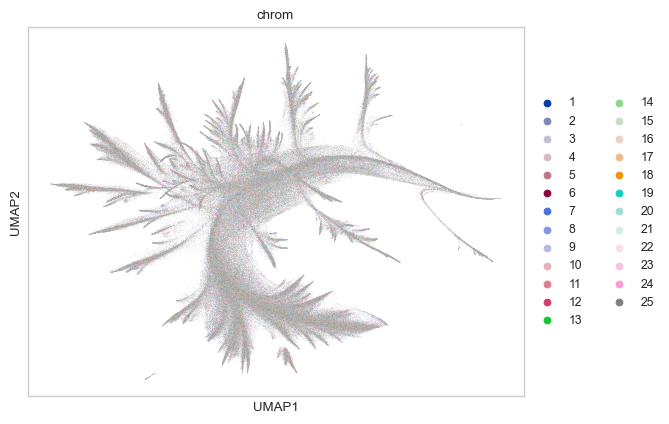

In [37]:
# plot the umap - colored by chromosome
sc.pl.umap(adata_peaks, color=["chrom"])

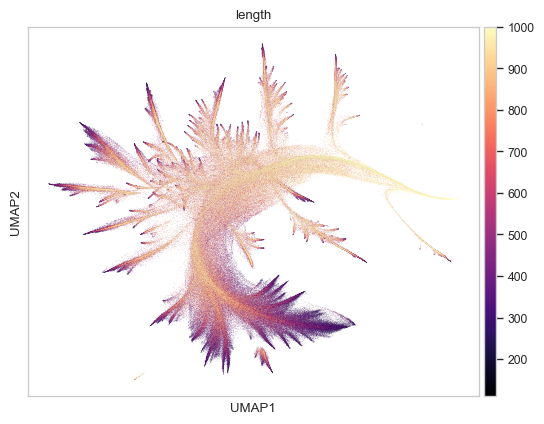

In [102]:
# plot the umap - colored by the peak width
# sc.pl.umap(adata_peaks, color=["length"], vmax=1000, save="_peak_width.png")
sc.pl.umap(adata_peaks, color=["length"], vmax=1000, title="peak_width",
           color_map="magma", save="_peak_width_magma.png")

In [42]:
plt.scatter()

640830

In [43]:
dot_size = 120000/640830
dot_size

0.18725715088244932

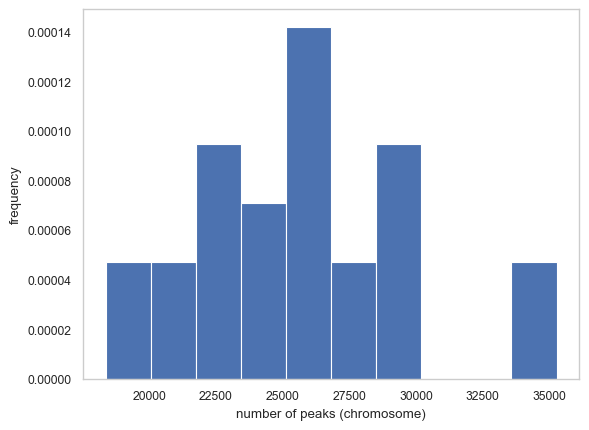

In [110]:
adata_peaks.obs["chrom"].value_counts().hist(bins=10, density=True)
plt.xlabel("number of peaks (chromosome)")
plt.ylabel("frequency")
plt.grid(False)
plt.show()

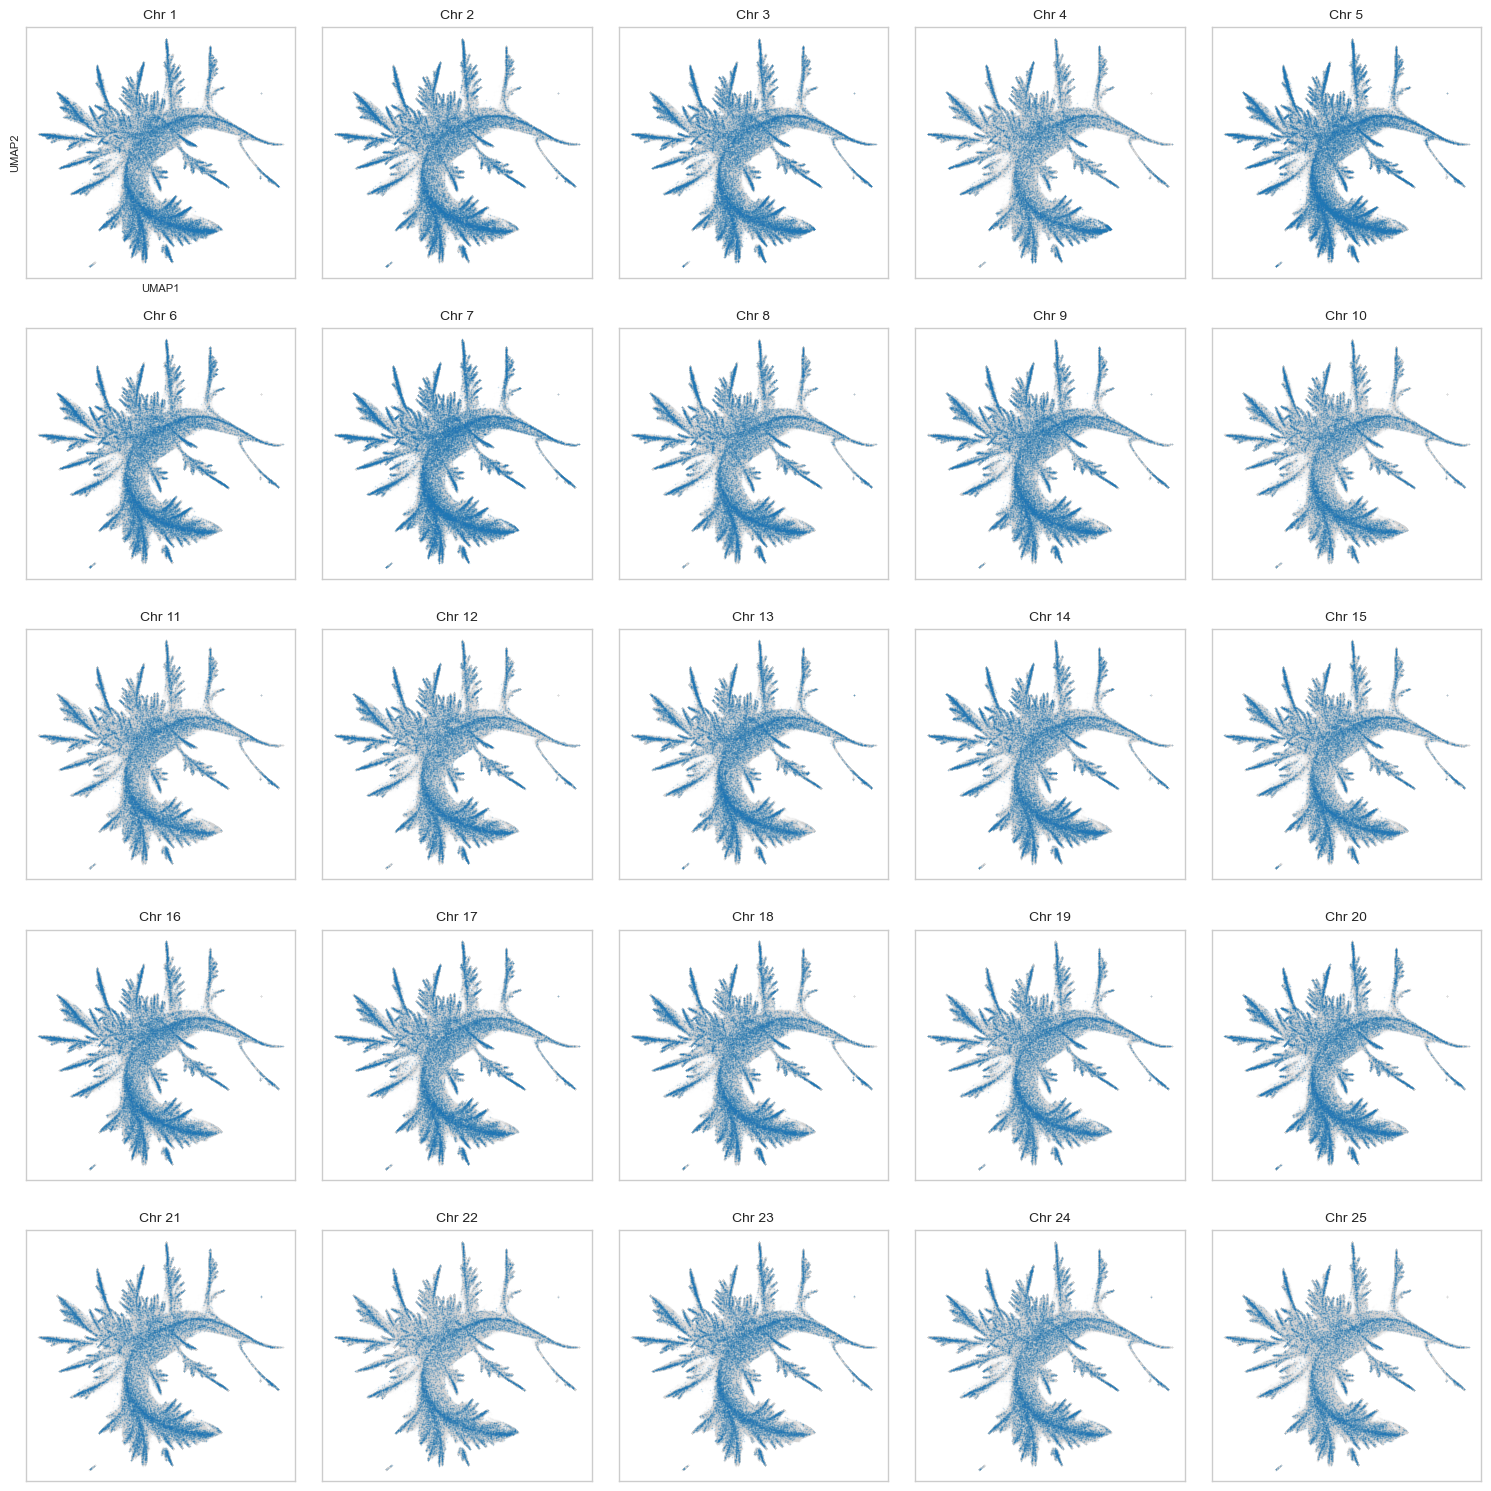

In [103]:
import matplotlib.gridspec as gridspec

# Create a 5x5 grid of subplots
fig = plt.figure(figsize=(15, 15))
gs = gridspec.GridSpec(5, 5, figure=fig)

# List of all chromosomes (as strings)
chromosomes = [str(i) for i in range(1, 26)]

# Loop through each chromosome and create a subplot
for i, chromosome in enumerate(chromosomes):
    # Get row and column index for the grid
    row = i // 5
    col = i % 5
    
    # Create subplot
    ax = fig.add_subplot(gs[row, col])
    
    # Get mask for current chromosome
    chrom_mask = adata_peaks.obs['chrom'] == chromosome
    
    # Plot non-highlighted chromosomes (grey, small, transparent)
    ax.scatter(
        adata_peaks.obsm['X_umap'][~chrom_mask, 0],
        adata_peaks.obsm['X_umap'][~chrom_mask, 1],
        c='lightgrey',
        s=0.005,  # Very small points for background
        alpha=0.2  # Very transparent
    )
    
    # Plot highlighted chromosome (red, larger, more opaque)
    ax.scatter(
        adata_peaks.obsm['X_umap'][chrom_mask, 0],
        adata_peaks.obsm['X_umap'][chrom_mask, 1],
        c='#1f77b4',
        s=0.01,  # Small but visible points
        alpha=0.8  # More opaque
    )
    
    # Set title to just the chromosome number
    ax.set_title(f'Chr {chromosome}', fontsize=10)
    
    # Remove axis ticks and labels
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    
    # Turn off grid
    ax.grid(False)
    
    # If this is the first subplot, add axis labels to the figure
    if i == 0:
        ax.set_xlabel('UMAP1', fontsize=8)
        ax.set_ylabel('UMAP2', fontsize=8)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(wspace=0.1, hspace=0.2)

# Add a main title
# plt.suptitle('UMAP by Chromosome', fontsize=16, y=0.92)

plt.savefig(figpath + "peak_umaps_chroms_each.png")
plt.savefig(figpath + "peak_umaps_chroms_each.pdf")
# Show the plot
plt.show()

In [57]:
adata_peaks.obs.head()

,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,accessibility_neural_optic,accessibility_endoderm,accessibility_enteric_neurons,accessibility_notochord,accessibility_pharyngeal_arches,accessibility_floor_plate,...,leiden_0.9,leiden_1,leiden_1.2,leiden_1.5,leiden_5,chrom,start,end,peak_type,length
1-32-526,131,2.694737,31.052632,512.0,15.613128,10.325988,6.689899,2.991895,12.762588,12.170900,...,26,16,19,28,33,1,32,526,intergenic,494
1-2372-3057,162,8.294737,14.736842,1576.0,57.789060,19.729371,42.719110,17.231317,22.624311,36.413397,...,1,2,1,2,126,1,2372,3057,intergenic,685
1-3427-4032,170,18.636842,10.526316,3541.0,94.465606,30.845398,105.145162,41.163118,72.624480,72.500155,...,6,6,5,7,30,1,3427,4032,intergenic,605
1-4469-7268,190,160.247368,0.000000,30447.0,568.299814,493.321985,480.077318,535.338964,641.692987,543.858841,...,4,4,6,4,101,1,4469,7268,exonic,2799
1-9541-9969,172,33.905263,9.473684,6442.0,118.378152,102.449880,65.013071,141.397103,178.130543,108.393402,...,6,6,5,7,30,1,9541,9969,promoter,428


In [33]:
adata_peaks

AnnData object with n_obs × n_vars = 640830 × 190
    obs: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'accessibility_neural_optic', 'accessibility_endoderm', 'accessibility_enteric_neurons', 'accessibility_notochord', 'accessibility_pharyngeal_arches', 'accessibility_floor_plate', 'accessibility_epidermis', 'accessibility_pronephros', 'accessibility_neural_floor_plate', 'accessibility_lateral_plate_mesoderm', 'accessibility_midbrain_hindbrain_boundary', 'accessibility_neural', 'accessibility_neurons', 'accessibility_neural_posterior', 'accessibility_neural_crest', 'accessibility_PSM', 'accessibility_fast_muscle', 'accessibility_endocrine_pancreas', 'accessibility_heart_myocardium', 'accessibility_neural_telencephalon', 'accessibility_optic_cup', 'accessibility_primordial_germ_cells', 'accessibility_differentiating_neurons', 'accessibility_muscle', 'accessibility_tail_bud', 'accessibility_hindbrain', 'accessibility_somites', 'accessibility_spinal_cord',


Peak type proportions:
intronic: 40.62%
intergenic: 36.36%
exonic: 18.89%
promoter: 4.12%


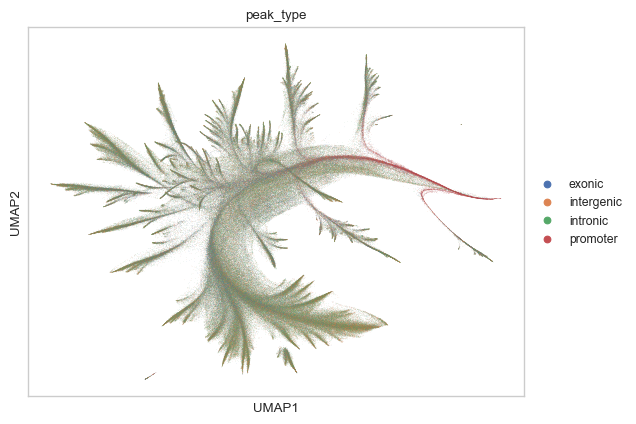

In [34]:
# Add annotations to adata object
# Calculate proportions
props = adata_peaks.obs['peak_type_argelaguet'].value_counts(normalize=True) * 100
print("\nPeak type proportions:")
for peak_type, prop in props.items():
    print(f"{peak_type}: {prop:.2f}%")

# Plot UMAP colored by peak type
sc.pl.umap(adata_peaks, color='peak_type_argelaguet', save="_peak_type_argelaguet_640K_peaks.png")

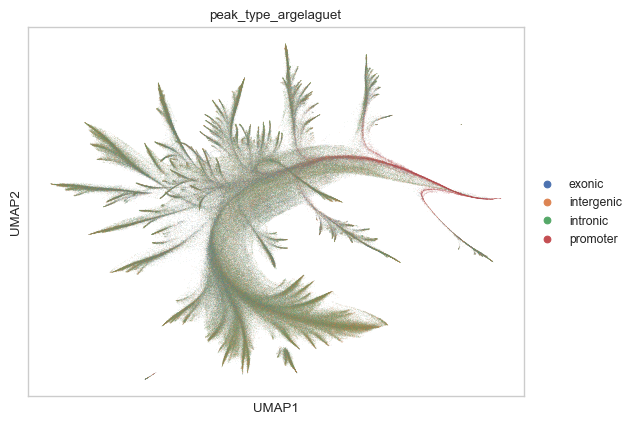

In [35]:
# Plot UMAP colored by peak type
sc.pl.umap(adata_peaks, color='peak_type_argelaguet', save="_peak_type_argelaguet_640K_peaks.png")

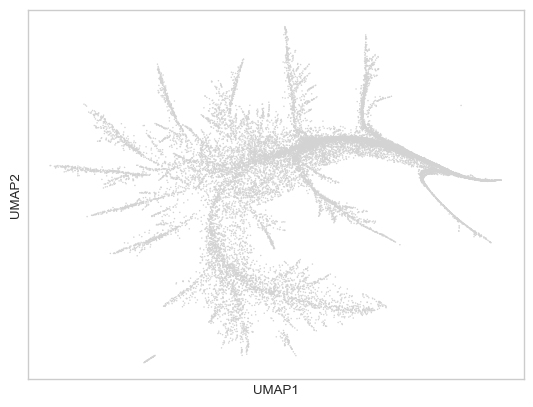

In [38]:
# subset for "promoter" only
sc.pl.umap(adata_peaks[adata_peaks.obs["peak_type_argelaguet"]=="promoter"],
           save="_peak_type_argelaguet_promoter_only.png")

/tmp/ipykernel_2870918/3011120066.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=peak_counts.index, y=peak_counts.values, ax=ax1,
/tmp/ipykernel_2870918/3011120066.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=peak_props.index, y=peak_props.values, ax=ax2,


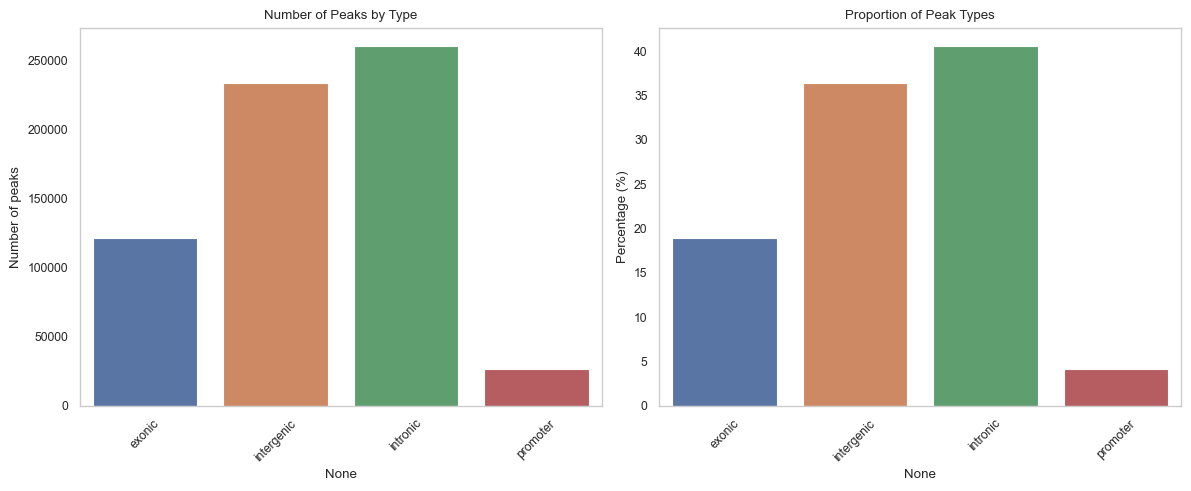

In [39]:
peak_counts = adata_peaks.obs['peak_type_argelaguet'].value_counts()
peak_props = adata_peaks.obs['peak_type_argelaguet'].value_counts(normalize=True) * 100

# Get the colors used for peak types in the UMAP
peak_type_colors = adata_peaks.uns['peak_type_colors']
peak_type_names = ['exonic', 'intergenic', 'intronic', 'promoter']  # Match the order in UMAP
color_dict = dict(zip(peak_type_names, peak_type_colors))

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot absolute counts with matching colors
sns.barplot(x=peak_counts.index, y=peak_counts.values, ax=ax1, 
           palette=color_dict)
ax1.set_title('Number of Peaks by Type')
ax1.set_ylabel('Number of peaks')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(False)

# Plot proportions with matching colors
sns.barplot(x=peak_props.index, y=peak_props.values, ax=ax2, 
           palette=color_dict)
ax2.set_title('Proportion of Peak Types')
ax2.set_ylabel('Percentage (%)')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(False)

# Add value labels on top of bars
# for i, v in enumerate(peak_counts):
#     ax1.text(i, v, f'{v:,}', ha='center', va='bottom')
# for i, v in enumerate(peak_props):
#     ax2.text(i, v, f'{v:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(figpath+'peak_type_distributions_argelaguet.pdf', dpi=300, bbox_inches='tight')
plt.show()

## annotate the peaks based on the genes in proximity



In [75]:
# from peak_annotation_utils import associate_peaks_to_genes

In [78]:
def associate_peaks_to_genes(adata_peaks, gtf_file, max_distance=50000, chunk_size=1000):
    """
    Associate peaks with genes using chunked processing to reduce memory usage
    """
    import pyranges as pr
    import pandas as pd
    import numpy as np
    from tqdm import tqdm
    
    # Create DataFrame from obs_names (which contain the coordinates)
    print("Preparing peak coordinates...")
    coords = [x.split('-') for x in adata_peaks.obs.index]
    peaks_df = pd.DataFrame(coords, columns=['Chromosome', 'Start', 'End'])
    
    # Convert Start and End to integers
    peaks_df['Start'] = peaks_df['Start'].astype(int)
    peaks_df['End'] = peaks_df['End'].astype(int)
    
    # Add peak_type from obs if it exists
    if 'peak_type' in adata_peaks.obs:
        peaks_df['peak_type'] = adata_peaks.obs['peak_type']
    
    # Create PyRanges object for peaks
    print("Initializing...")
    peaks_gr = pr.PyRanges(peaks_df)
    
    # Read GTF file and get genes
    print("Reading GTF file...")
    gtf = pr.read_gtf(gtf_file)
    genes = gtf[gtf.Feature == 'gene']
    
    print("Processing TSS coordinates...")
    # Create TSS coordinates for + and - strands separately
    plus_tss = genes[genes.Strand == '+'].copy()
    plus_tss.End = plus_tss.Start + 1
    
    minus_tss = genes[genes.Strand == '-'].copy()
    minus_tss.Start = minus_tss.End - 1
    
    # Combine TSS coordinates
    tss = pr.concat([plus_tss, minus_tss])
    
    # Initialize results DataFrame
    result_df = peaks_df.copy()
    result_df['gene_body_overlaps'] = ''
    result_df['nearest_gene'] = ''
    result_df['distance_to_tss'] = np.nan
    
    # Process in chunks
    total_chunks = len(peaks_df) // chunk_size + (1 if len(peaks_df) % chunk_size else 0)
    
    for chunk_idx in tqdm(range(total_chunks), desc="Processing peaks in chunks"):
        start_idx = chunk_idx * chunk_size
        end_idx = min((chunk_idx + 1) * chunk_size, len(peaks_df))
        
        # Get chunk of peaks
        chunk_peaks = peaks_df.iloc[start_idx:end_idx]
        chunk_gr = pr.PyRanges(chunk_peaks)
        
        # Find overlaps for this chunk
        gene_overlaps = chunk_gr.join(genes, suffix='_gene', apply_strand_suffix=False)
        nearest_tss = chunk_gr.nearest(tss, suffix='_tss', apply_strand_suffix=False)
        
        # Process gene body overlaps
        if not gene_overlaps.empty:
            overlaps_df = gene_overlaps.as_df()
            overlaps_df['gene_name'] = overlaps_df['gene_name'].astype(str)
            
            # Group by peak coordinates
            for _, peak_group in overlaps_df.groupby(['Chromosome', 'Start', 'End']):
                peak_genes = ','.join(set(peak_group['gene_name']))
                idx = result_df[
                    (result_df['Chromosome'] == peak_group['Chromosome'].iloc[0]) &
                    (result_df['Start'] == peak_group['Start'].iloc[0]) &
                    (result_df['End'] == peak_group['End'].iloc[0])
                ].index
                result_df.loc[idx, 'gene_body_overlaps'] = peak_genes
        
        # Process nearest TSS
        if not nearest_tss.empty:
            nearest_df = nearest_tss.as_df()
            nearest_df['gene_name'] = nearest_df['gene_name'].astype(str)
            
            for _, row in nearest_df.iterrows():
                peak_center = (row['Start'] + row['End']) // 2
                # Use the regular Strand column instead of Strand_tss
                tss_pos = row['Start_tss'] if row['Strand'] == '+' else row['End_tss']
                distance = abs(peak_center - tss_pos)
                
                if distance <= max_distance:
                    idx = result_df[
                        (result_df['Chromosome'] == row['Chromosome']) &
                        (result_df['Start'] == row['Start']) &
                        (result_df['End'] == row['End'])
                    ].index
                    result_df.loc[idx, 'nearest_gene'] = row['gene_name']
                    result_df.loc[idx, 'distance_to_tss'] = distance
    
    # Reset the index to match the original AnnData
    result_df.index = adata_peaks.obs_names
    
    return result_df

In [79]:
# Try the association with chunked processing
try:
    print("Starting peak to gene association...")
    peaks_with_genes = associate_peaks_to_genes(
        adata_peaks,
        '/hpc/reference/sequencing_alignment/alignment_references/zebrafish_genome_GRCz11/genes/genes.gtf.gz',
        chunk_size=1000
    )
    
    print("\nProcessing results...")
    with tqdm(total=3, desc="Adding annotations") as pbar:
        # Print statistics
        print("\nPeaks overlapping gene bodies:", 
              (peaks_with_genes['gene_body_overlaps'] != '').sum())
        print("Peaks with nearest gene within 50kb:", 
              (peaks_with_genes['nearest_gene'] != '').sum())
        pbar.update(1)
        
        # Add gene body overlaps
        adata_peaks.obs['gene_body_overlaps'] = peaks_with_genes['gene_body_overlaps']
        pbar.update(1)
        
        # Add nearest gene and distance
        adata_peaks.obs['nearest_gene'] = peaks_with_genes['nearest_gene']
        adata_peaks.obs['distance_to_tss'] = peaks_with_genes['distance_to_tss']
        pbar.update(1)
        
except Exception as e:
    print(f"Error occurred: {str(e)}")
    print("\nFull error details:")
    import traceback
    traceback.print_exc()

Starting peak to gene association...
Preparing peak coordinates...
Initializing...
Reading GTF file...
Processing TSS coordinates...


Processing peaks in chunks: 100%|██████████| 641/641 [17:18:53<00:00, 97.24s/it]   


Processing results...
Error occurred: name 'tqdm' is not defined

Full error details:



Traceback (most recent call last):
  File "/tmp/ipykernel_1007319/326503447.py", line 11, in <module>
    with tqdm(total=3, desc="Adding annotations") as pbar:
NameError: name 'tqdm' is not defined


In [88]:
peaks_with_genes.head()

,Chromosome,Start,End,peak_type,gene_body_overlaps,nearest_gene,distance_to_tss
1-32-526,1,32,526,NaN,,cep97,11542.0
1-2372-3057,1,2372,3057,NaN,,cep97,9107.0
1-3427-4032,1,3427,4032,NaN,,cep97,8092.0
1-4469-7268,1,4469,7268,NaN,rpl24,cep97,5953.0
1-9541-9969,1,9541,9969,NaN,rpl24,cep97,2066.0


In [87]:
# Print statistics
print("\nPeaks overlapping gene bodies:", 
      (peaks_with_genes['gene_body_overlaps'] != '').sum())
print("Peaks with nearest gene within 50kb:", 
      (peaks_with_genes['nearest_gene'] != '').sum())

# Add gene body overlaps
adata_peaks.obs['gene_body_overlaps'] = peaks_with_genes['gene_body_overlaps']

# Add nearest gene and distance
adata_peaks.obs['nearest_gene'] = peaks_with_genes['nearest_gene']
adata_peaks.obs['distance_to_tss'] = peaks_with_genes['distance_to_tss']

adata_peaks.obs.head()


Peaks overlapping gene bodies: 405857
Peaks with nearest gene within 50kb: 500582


,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,accessibility_neural_optic,accessibility_endoderm,accessibility_enteric_neurons,accessibility_notochord,accessibility_pharyngeal_arches,accessibility_floor_plate,...,leiden_1.5,leiden_5,chrom,start,end,peak_type,length,gene_body_overlaps,nearest_gene,distance_to_tss
1-32-526,131,2.694737,31.052632,512.0,15.613128,10.325988,6.689899,2.991895,12.762588,12.170900,...,28,33,1,32,526,intergenic,494,,cep97,11542.0
1-2372-3057,162,8.294737,14.736842,1576.0,57.789060,19.729371,42.719110,17.231317,22.624311,36.413397,...,2,126,1,2372,3057,intergenic,685,,cep97,9107.0
1-3427-4032,170,18.636842,10.526316,3541.0,94.465606,30.845398,105.145162,41.163118,72.624480,72.500155,...,7,30,1,3427,4032,intergenic,605,,cep97,8092.0
1-4469-7268,190,160.247368,0.000000,30447.0,568.299814,493.321985,480.077318,535.338964,641.692987,543.858841,...,4,101,1,4469,7268,exonic,2799,rpl24,cep97,5953.0
1-9541-9969,172,33.905263,9.473684,6442.0,118.378152,102.449880,65.013071,141.397103,178.130543,108.393402,...,7,30,1,9541,9969,promoter,428,rpl24,cep97,2066.0


In [89]:
# Basic statistics for gene body overlaps
print("Gene Body Overlap Statistics:")
print("-" * 30)
# Count peaks with no gene body overlaps
no_body_overlaps = (adata_peaks.obs['gene_body_overlaps'] == '').sum()
total_peaks = len(adata_peaks.obs)
print(f"Peaks with no gene body overlaps: {no_body_overlaps} ({(no_body_overlaps/total_peaks)*100:.2f}%)")

# Count peaks with gene body overlaps
has_body_overlaps = (adata_peaks.obs['gene_body_overlaps'] != '').sum()
print(f"Peaks with gene body overlaps: {has_body_overlaps} ({(has_body_overlaps/total_peaks)*100:.2f}%)")

# Distribution of number of overlapping genes per peak
overlapping_gene_counts = adata_peaks.obs['gene_body_overlaps'].apply(
    lambda x: len(x.split(',')) if isinstance(x, str) and x != '' else 0
)
print("\nDistribution of number of overlapping genes per peak:")
print(overlapping_gene_counts.value_counts().sort_index())

print("\nNearest Gene Statistics:")
print("-" * 30)
# Count peaks with no nearest gene
no_nearest = adata_peaks.obs['nearest_gene'].isna().sum()
print(f"Peaks with no nearest gene: {no_nearest} ({(no_nearest/total_peaks)*100:.2f}%)")
print(f"Peaks with nearest gene assigned: {total_peaks - no_nearest} ({((total_peaks-no_nearest)/total_peaks)*100:.2f}%)")

# Distance to TSS statistics
print("\nDistance to TSS Statistics (for peaks with nearest gene):")
print(adata_peaks.obs['distance_to_tss'].describe())

# Overlap between methods
both_methods = ((adata_peaks.obs['gene_body_overlaps'] != '') & 
                (~adata_peaks.obs['nearest_gene'].isna())).sum()
only_body = ((adata_peaks.obs['gene_body_overlaps'] != '') & 
             (adata_peaks.obs['nearest_gene'].isna())).sum()
only_nearest = ((adata_peaks.obs['gene_body_overlaps'] == '') & 
                (~adata_peaks.obs['nearest_gene'].isna())).sum()
no_association = ((adata_peaks.obs['gene_body_overlaps'] == '') & 
                 (adata_peaks.obs['nearest_gene'].isna())).sum()

Gene Body Overlap Statistics:
------------------------------
Peaks with no gene body overlaps: 234973 (36.67%)
Peaks with gene body overlaps: 405857 (63.33%)

Distribution of number of overlapping genes per peak:
0     234973
1     385384
2      18966
3       1235
4        128
5         36
6         17
7          5
8          8
9         24
10         6
11         5
12        13
13        22
14         2
15         1
16         1
17         1
18         3
Name: gene_body_overlaps, dtype: int64

Nearest Gene Statistics:
------------------------------
Peaks with no nearest gene: 0 (0.00%)
Peaks with nearest gene assigned: 640830 (100.00%)

Distance to TSS Statistics (for peaks with nearest gene):
count    500582.000000
mean      16581.162521
std       13310.484481
min           0.000000
25%        5513.000000
50%       13096.000000
75%       25457.000000
max       50000.000000
Name: distance_to_tss, dtype: float64


In [91]:
# check how many peaks were annotated by associated "genes"
adata_peaks.obs["nearest_gene"].value_counts()

                  140248
nan                  970
robo2                104
si:dkey-16p6.1        99
adcyap1r1a            91
                   ...  
si:dkey-84o3.6         1
dre-mir-192            1
selenoh                1
ppm1da                 1
CU929339.1             1
Name: nearest_gene, Length: 29836, dtype: int64

In [92]:
adata_peaks.write_h5ad("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/objects_v2/peaks_by_pb_leiden_0.4_merged_annotated_filtered.h5ad")

### generating UMAPs

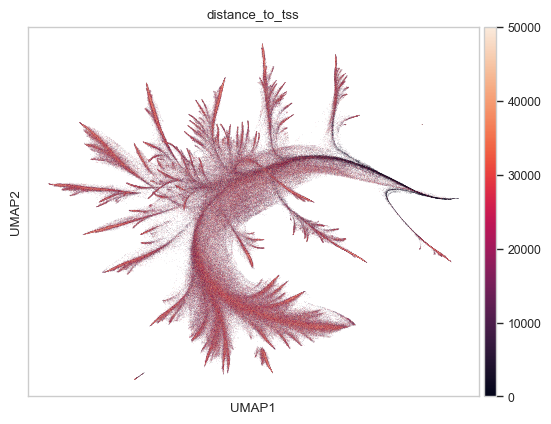

In [93]:
sc.pl.umap(adata_peaks, color=["distance_to_tss"], 
           vmin=0, vmax=50000,
           save="_peaks_distance_to_tss.png")

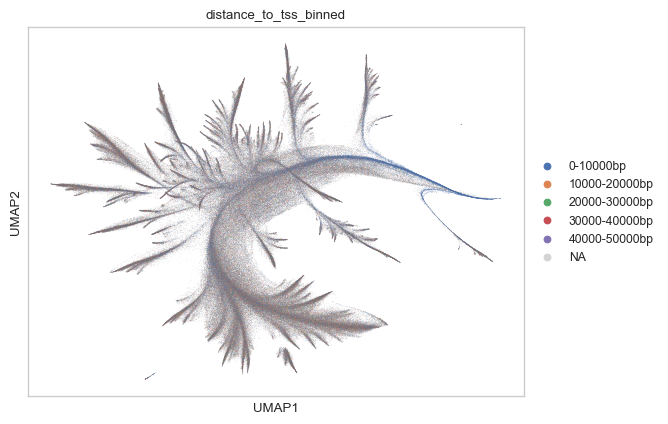

In [94]:
# Create bins every 10000bp
bins = np.arange(0, 60000, 10000)  # Going up to 50000 to ensure we capture all values
labels = [f'{bins[i]}-{bins[i+1]}bp' for i in range(len(bins)-1)]

# Create binned column
adata_peaks.obs['distance_to_tss_binned'] = pd.cut(
    adata_peaks.obs['distance_to_tss'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Plot UMAP with binned distances
sc.pl.umap(adata_peaks, 
           color='distance_to_tss_binned',
           save='_peaks_distance_binned.png')

In [95]:
# sanity check using the "myf5" locus as an example
adata_peaks[adata_peaks.obs_names.str.startswith("4-2174")].obs

,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,accessibility_neural_optic,accessibility_endoderm,accessibility_enteric_neurons,accessibility_notochord,accessibility_pharyngeal_arches,accessibility_floor_plate,...,leiden_5,chrom,start,end,peak_type,length,gene_body_overlaps,nearest_gene,distance_to_tss,distance_to_tss_binned
4-21740900-21741774,178,96.552632,6.315789,18345.0,112.689338,160.381270,138.280225,149.904792,227.851425,93.103144,...,92,4,21740900,21741774,promoter,874,myf5,myf5,110.0,0-10000bp
4-21743122-21743613,157,15.078947,17.368421,2865.0,13.759470,78.388094,21.888137,33.535603,42.642490,12.381235,...,92,4,21743122,21743613,promoter,491,myf5,BX537156.1,495.0,0-10000bp
4-21743990-21744588,149,8.084211,21.578947,1536.0,10.622719,35.078771,19.877272,7.646023,22.016727,8.780761,...,116,4,21743990,21744588,exonic,598,myf5,BX537156.1,427.0,0-10000bp
4-21745018-21745515,159,32.215789,16.315789,6121.0,24.452766,39.828491,24.337701,50.402955,37.060058,28.153174,...,92,4,21745018,21745515,exonic,497,myf5,BX537156.1,1404.0,0-10000bp
4-21745790-21746582,168,35.989474,11.578947,6838.0,35.209522,59.361978,61.662125,65.844548,50.106557,38.720573,...,92,4,21745790,21746582,intergenic,792,,BX537156.1,2324.0,0-10000bp
4-21747791-21748437,166,11.515789,12.631579,2188.0,25.344952,65.009398,54.817082,39.044852,38.142695,20.808292,...,66,4,21747791,21748437,intergenic,646,,BX537156.1,4252.0,0-10000bp


NOTE that the gene_body_overlaps doesn't necessarily mean that the "nearest_gene" would be the same.

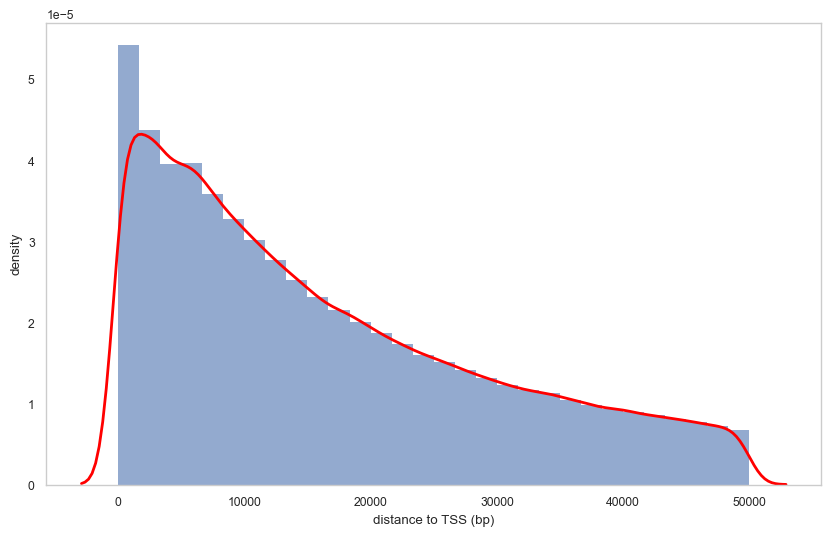

In [96]:
# Create histogram with no gaps and KDE
fig, ax = plt.subplots(figsize=(10, 6))

# Plot histogram
adata_peaks.obs.distance_to_tss.hist(bins=30, density=True, 
                                         histtype='bar', 
                                         edgecolor='none',
                                         alpha=0.6,  # Make bars slightly transparent
                                         rwidth=1.0)  # Remove gaps between bars

# Add KDE
sns.kdeplot(data=adata_peaks.obs.distance_to_tss, 
            color='red', 
            linewidth=2)

plt.xlabel("distance to TSS (bp)")
plt.ylabel("density")
plt.grid(False)
plt.savefig(figpath + "hist_peaks_distance_to_tss.pdf")
plt.show()

In [97]:
adata_peaks.obs["distance_to_tss_binned"].value_counts()

0-10000bp        205142
10000-20000bp    123406
20000-30000bp     78687
30000-40000bp     53989
40000-50000bp     39358
Name: distance_to_tss_binned, dtype: int64

In [105]:
# export the metadata
adata_peaks.obs.to_csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/objects_v2/all_peaks_annotated.csv")